# Initialize

In [1]:
#General packages
from IPython.display import clear_output #import of a single funtcion
import sys #system related packages
import os #better path and file handling
import pickle #saving and loading objects

#Tables, numbers etc
import pandas as pd #tables
import numpy as np #arrays
import scipy #sciency functions
from sklearn import mixture #For gaussian mixture model

#Plotting packages
import matplotlib.pyplot as plt #Main plotting'
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sbn #nicer plots

#RNA-seq analysis
import scanpy as sc #Main package for scRNA-seq analysis
import scanpy.external as sce #some more functions for scanpy
import bbknn #batch correction


#Import some custom helper functions for plotting
path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao'
sys.path.append(path_skin_scripts)
from Constants import *
from Hierarchy_functions import *
#from spatial_functions import *

import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = False
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter("ignore")

/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


# Read

In [2]:
core_metadata = pd.read_csv('/mnt/p/users/nil/projects/integrated_hsca/data/20260520_master_metadata.csv', sep=',', index_col=0)
core_metadata = core_metadata[~core_metadata['sequencing_platform'].isin(['MERFISH','StereoSeq','Xenium'])] # remove spatial data

## Unify and sensibilize metadata

In [3]:
adata = sc.read_h5ad('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/MetaStudiesAnalysis/Integration/Output/Integration/v70_Extension_Tolga_Hao/adata_all_KNN_mapping_renamed.h5ad')
core_metadata = pd.read_csv('/mnt/p/users/nil/projects/integrated_hsca/data/20260520_master_metadata.csv', sep=',', index_col=0)
core_metadata = core_metadata[~core_metadata['sequencing_platform'].isin(['MERFISH','StereoSeq','Xenium'])] # remove spatial data

adata.obs = pd.merge(adata.obs, core_metadata[['region_L1','region_L2','region_L3']], left_index=True, right_index=True, how='left')

adata.obs["region_L1"] = adata.obs["region_L1"].fillna("extended-unassigned")
adata.obs["region_L2"] = adata.obs["region_L2"].fillna("extended-unassigned")
adata.obs["region_L3"] = adata.obs["region_L3"].fillna("extended-unassigned")

adata.obs.loc[adata.obs['region_L3'] == 'extended-unassigned', 'region_L3'] = adata.obs.loc[adata.obs['region_L3'] == 'extended-unassigned', 'anatomical_region_level_3']
adata.obs.loc[adata.obs['anatomical_region_level_2'].isin(['Breast','Chest','Neck']), 'region_L3'] = adata.obs.loc[adata.obs['anatomical_region_level_2'].isin(['Breast','Chest','Neck']), 'anatomical_region_level_2']
adata.obs.loc[adata.obs['region_L3'] == 'Pannus', 'region_L3']     = "Periumbilical"
adata.obs.loc[adata.obs['region_L3'] == 'Upper thigh', 'region_L3'] = "Thigh"
adata.obs.loc[adata.obs['region_L3'] == 'Inner upper arm', 'region_L3'] = "Upper arm"

def add_L1_L2_site_regions(data, L1_col, L2_col, L3_col):

    # modified for extended data

    data[L2_col] = 'unassigned'
    data.loc[data[L3_col].isin(['Antecubital fossa', 'Forearm', 'Upper arm', 'Shoulder', 'Elbow', 'Axilla']), L2_col] = 'Arm'
    data.loc[data[L3_col].isin(['Dorsal foot', 'Heel', 'Plantar']), L2_col] = 'Foot'
    data.loc[data[L3_col].isin(['Dorsal hand', 'Palm']), L2_col] = 'Hand'
    data.loc[data[L3_col].isin(['Calf', 'Knee', 'Shin', 'Thigh', 'Popliteal fossa']), L2_col] = 'Leg'
    data.loc[data[L3_col].isin(['Cheek', 'Eyelids', 'Forehead', 'Tragus', 'Postauricular', 'Infraorbital','Eyebrow', 'Nose','Temple','Jaw']), L2_col] = 'Face'
    data.loc[data[L3_col].isin(['Occipital', 'Vertex']), L2_col] = 'Scalp'
    data.loc[data[L3_col].isin(['Flank', 'Groins', 'Periumbilical', 'Hip', 'Inguinal fold']), L2_col] = 'Abdominal'
    data.loc[data[L3_col].isin(['Lower back', 'Upper back']), L2_col] = 'Back'
    data.loc[data[L3_col].isin(['Breast', 'Chest']), L2_col] = 'Pectoral'
    data.loc[data[L3_col].isin(['Foreskin']), L2_col] = 'Genitalia'
    data.loc[data[L3_col].isin(['Neck']), L2_col] = 'Neck'

    data['region_L1'] = 'unassigned'
    data.loc[data['region_L2'].isin(['Arm','Foot','Hand','Leg']), L1_col] = 'Extremities'
    data.loc[data['region_L2'].isin(['Face','Scalp','Neck']), L1_col] = 'Head'
    data.loc[data['region_L2'].isin(['Abdominal','Back','Genitalia','Pectoral']),   L1_col] = 'Torso'
    return data

adata.obs = add_L1_L2_site_regions(adata.obs, L1_col='region_L1', L2_col='region_L2', L3_col='region_L3')

# Fix sample ids and study ids

adata.obs['sample_id'] = adata.obs['sample_id_running'].astype(str)
adata.obs['donor_id']  = adata.obs['sample_id_running'].astype(str)
belote_samples_to_fix = ['Belote_Torres_NatureCellBiology_2021___A1038LM', 'Belote_Torres_NatureCellBiology_2021___A1046M']
adata.obs.loc[adata.obs['sample_id'].isin(belote_samples_to_fix), 'sample_id'] = adata.obs.loc[adata.obs['sample_id'].isin(belote_samples_to_fix), 'sample_id'].astype(str) + '_' + adata.obs.loc[adata.obs['sample_id'].isin(belote_samples_to_fix), 'region_L3'].astype(str)
adata.obs.loc[adata.obs['study_id']=='SS3E_Human_Skin_20K', 'sample_id'] = adata.obs.loc[adata.obs['study_id']=='SS3E_Human_Skin_20K', 'sample_id'].astype(str) + '_' + adata.obs.loc[adata.obs['study_id']=='SS3E_Human_Skin_20K', 'region_L3'].astype(str)

adata.obs['study_id'] = adata.obs['study_id'].astype(str)
adata.obs.loc[adata.obs['study_id']=='SS3E_Human_Skin_20K', 'study_id'] = 'Yuan_in_prep'
adata.obs["study_short"] = adata.obs["study_id"].str.split('_').str[0] + " " + adata.obs["study_id"].str.split('_').str[-1]

adata.obs.loc[adata.obs['study_id']=='Boldo_Lyko_CommunicationsBiology_2020', 'study_id'] = 'Sole-Boldo_Lyko_CommunicationsBiology_2020'
adata.obs.loc[adata.obs['study_short']=='Boldo 2020', 'study_short'] = 'Sole-Boldo 2020'

adata.obs['study_short'] = adata.obs['study_short'].astype(str)
adata.obs.loc[adata.obs['sample_id'].str.startswith('He_Guo'), 'study_short'] = "He Guo 2020"
adata.obs.loc[adata.obs['sample_id'].str.startswith('He_Guttman'), 'study_short'] = "He Guttman 2020"

# Add KNN labels
knn_labels = pd.read_csv('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/MetaStudiesAnalysis/Integration/Output/Integration/v70_Extension_Tolga_Hao/v70_Extension_Tolga_Haointegrated_annotation_L2_k_NN.csv', index_col=0)
knn_labels['integrated_annotation_L1_k-NN'] = knn_labels['integrated_annotation_L2_k-NN'].str.split(' - ').str[0]
print(sum(knn_labels['integrated_annotation_L1_k-NN'].isna()))
adata.obs = pd.merge(adata.obs, knn_labels['integrated_annotation_L1_k-NN'], how='left', left_index=True, right_index=True)
adata = adata[~adata.obs['integrated_annotation_L1_k-NN'].isna()]# Remove cells with missing label

2827


In [5]:
extension_datasets = adata.obs.dropna(subset = 'DataType_Extension')['study_id'].unique()

In [11]:
extended_filter = adata.obs['study_id'].isin(extension_datasets)

In [23]:
[print(i) for i in adata.obs.loc[extended_filter, 'study_id'].unique()]

Liu_Landen_CellStemCell_2025
Zhou_Zheng_2024
He_Guo_2020
Wang_Xie_2025
Li_Church_2025
Ahlers_Siracusa_2022
Zheng_Zhao_2022
Singh_Sen_2022
Rustagi_Singh_2022
Bangert_Brunner_2024
Sun_Liu_2022
Mariottoni_MacLeod_2021
Direder_Mildner_2022
Chu_Midha_2022
Reynolds_Haniffa_Science_2021
Forsthuber_Lichtenberger_NatureCommunications_2024
Kim_Krueger_JournalofAllergyandClinicalImmunology_2021


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [20]:
len(adata.obs.loc[extended_filter, 'donor_id'].unique())

97

In [16]:
ext_data.obs['study_short'].unique()

array(['Liu 2025', 'He 2020', 'Zhou 2024', 'Wang 2025', 'Li 2025',
       'Ahlers 2022', 'Zheng 2022', 'Singh 2022', 'Rustagi 2022',
       'Bangert 2024', 'Sun 2022', 'Mariottoni 2021', 'Direder 2022',
       'Chu 2022', 'Reynolds 2021', 'Forsthuber 2024', 'Kim 2021'],
      dtype=object)

In [17]:
ext_data.obs['study_id'].value_counts()

study_id
Reynolds_Haniffa_Science_2021                             195642
Ahlers_Siracusa_2022                                       74310
Li_Church_2025                                             55852
Zheng_Zhao_2022                                            52824
Wang_Xie_2025                                              42164
Liu_Landen_CellStemCell_2025                               37002
He_Guttman_JournalofAllergyandClinicalImmunology_2020      27463
Singh_Sen_2022                                             22691
Bangert_Brunner_2024                                       17892
Rustagi_Singh_2022                                         13781
Chu_Midha_2022                                             13592
Sun_Liu_2022                                               10178
Direder_Mildner_2022                                        9593
Zhou_Zheng_2024                                             8923
He_Guo_2020                                                 7434
Mariottoni_MacLe

# Re-calculate QC

In [4]:
adata.var["mito"] = adata.var['feature_name'].astype(str).str.startswith("MT-")

In [5]:
sc.pp.calculate_qc_metrics(adata, layer = 'raw_counts', qc_vars = 'mito', inplace = True, parallel = True)

## Plot

In [56]:
def add_annotations(study_col = 'study_fix'):
    donors = plot_df[x].unique()
    donor_to_idx = {donor: i for i, donor in enumerate(donors)}
    ticks = []
    for study, sub_df in plot_df.groupby(study_col, observed=True):
        # Find the range of indices for this study
        indices = [donor_to_idx[d] for d in sub_df[x].unique()]
        start, end = min(indices), max(indices)
        study_mean = sub_df[y].mean()

        d_ix = -1
        for d in sub_df[x].unique():
            ticks.append(str(d_ix := d_ix+1))
       
        # Draw Background Mean Line (zorder=0 puts it behind violins)
        ax.hlines(y=study_mean, xmin=start-0.5, xmax=end+0.5, 
                  colors='k', linestyles=':', linewidth=1, zorder=0)
        
        # Draw Vertical Separator (at the end of the study block)
        if end < len(donors) - 1:
            ax.axvline(x=end + 0.5, color='lightgray', linestyle='-', linewidth=1)
        
        # 4. Add Study Annotations below X-axis
        # Position is slightly below the plot (adjust y_pos based on your data scale)
        y_min, y_max = ax.get_ylim()
        y_pos = -0.3
        
        if ix == (len(qc_metrics)-1):
            # Horizontal line under donors
            ax.plot([start, end], [y_pos, y_pos], color='black', transform=ax.get_xaxis_transform(), clip_on=False)
            # Study ID Text
            ax.text((start + end) / 2, y_pos+(y_pos/2), f'{study.split('_')[0]}\n{study.split('_')[-1]}', ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontweight='regular', fontsize = 6, rotation = 90)
        [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
        if ix == 0:
            [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
        else:
            [ax.spines[spine].set_visible(False) for spine in ['right']]
    return ticks

In [46]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/QC'
x = 'donor_id'
plot_df = adata.obs.copy()

plot_df["study_short"] = pd.Categorical(
    plot_df["study_short"],
    categories=natsorted(plot_df["study_short"].dropna().unique()),
    ordered=True)
plot_df = plot_df[plot_df['study_short'].isin(extension_datasets)].copy()
plot_df = plot_df.sort_values(by = 'study_short')

plot_df

,study_id,experiment_id,institute,author_batch_notes,organism,organism_ontology_term_id,donor_id,donor_id_running,sex_ontology_term,sex_ontology_term_id,...,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
PRJNA754272_SRR15440580_AAACCTGAGAATCTCC-1,Ahlers_Siracusa_2022,Ahlers_Siracusa_2022,unknown,unknown,Homo sapiens,NCBITaxon:9606,Ahlers_Siracusa_2022___PRJNA754272_S1,Ahlers_Siracusa_2022___PRJNA754272_S1,female,PATO:0000383,...,7.063048,2563.0,7.849324,32.774093,44.947327,57.783847,73.975810,21.0,3.091042,0.819352
PRJNA754272_SRR15440585_GGACAAGTCTCGGACG-1,Ahlers_Siracusa_2022,Ahlers_Siracusa_2022,unknown,unknown,Homo sapiens,NCBITaxon:9606,Ahlers_Siracusa_2022___PRJNA754272_S6,Ahlers_Siracusa_2022___PRJNA754272_S6,female,PATO:0000383,...,6.857514,2104.0,7.652071,36.074144,47.053232,60.266160,78.612167,27.0,3.332205,1.283270
PRJNA754272_SRR15440585_GGACAAGTCTGCCCTA-1,Ahlers_Siracusa_2022,Ahlers_Siracusa_2022,unknown,unknown,Homo sapiens,NCBITaxon:9606,Ahlers_Siracusa_2022___PRJNA754272_S6,Ahlers_Siracusa_2022___PRJNA754272_S6,female,PATO:0000383,...,7.042286,2423.0,7.793174,32.562939,43.871234,56.004953,73.462650,24.0,3.218876,0.990508
PRJNA754272_SRR15440585_GGACAGAAGTAGCCGA-1,Ahlers_Siracusa_2022,Ahlers_Siracusa_2022,unknown,unknown,Homo sapiens,NCBITaxon:9606,Ahlers_Siracusa_2022___PRJNA754272_S6,Ahlers_Siracusa_2022___PRJNA754272_S6,female,PATO:0000383,...,7.276556,3416.0,8.136518,29.449649,41.832553,55.386417,72.336066,57.0,4.060443,1.668618
PRJNA754272_SRR15440585_GGACAGACACCAGCAC-1,Ahlers_Siracusa_2022,Ahlers_Siracusa_2022,unknown,unknown,Homo sapiens,NCBITaxon:9606,Ahlers_Siracusa_2022___PRJNA754272_S6,Ahlers_Siracusa_2022___PRJNA754272_S6,female,PATO:0000383,...,7.012115,2943.0,7.987524,35.474006,50.152905,63.574584,79.306830,39.0,3.688879,1.325178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM8478430_GTACAGTAGGTCCCGT-1,Zhou_Zheng_2024,Zhou_Zheng_2024,unknown,unknown,Homo sapiens,NCBITaxon:9606,Zhou_Zheng_2024___GSE275491_S1,Zhou_Zheng_2024___GSE275491_S1,female,PATO:0000383,...,7.305860,3679.0,8.210668,29.546072,42.294102,54.688774,72.954607,77.0,4.356709,2.092960
GSM8478430_GTACAGTAGGTGCTAG-1,Zhou_Zheng_2024,Zhou_Zheng_2024,unknown,unknown,Homo sapiens,NCBITaxon:9606,Zhou_Zheng_2024___GSE275491_S1,Zhou_Zheng_2024___GSE275491_S1,female,PATO:0000383,...,7.916807,9524.0,9.161675,28.401932,41.012180,54.325913,68.647627,43.0,3.784190,0.451491
GSM8478430_GTACAGTAGGTTAAAC-1,Zhou_Zheng_2024,Zhou_Zheng_2024,unknown,unknown,Homo sapiens,NCBITaxon:9606,Zhou_Zheng_2024___GSE275491_S1,Zhou_Zheng_2024___GSE275491_S1,female,PATO:0000383,...,5.877736,547.0,6.306275,36.563071,53.199269,71.480804,100.000000,15.0,2.772589,2.742230
GSM8478430_GTACAACTCGCTTTAT-1,Zhou_Zheng_2024,Zhou_Zheng_2024,unknown,unknown,Homo sapiens,NCBITaxon:9606,Zhou_Zheng_2024___GSE275491_S1,Zhou_Zheng_2024___GSE275491_S1,female,PATO:0000383,...,7.417580,3281.0,8.096208,24.839988,34.593112,46.235904,64.523011,91.0,4.521789,2.773545


## Fig S1e

[None, None]

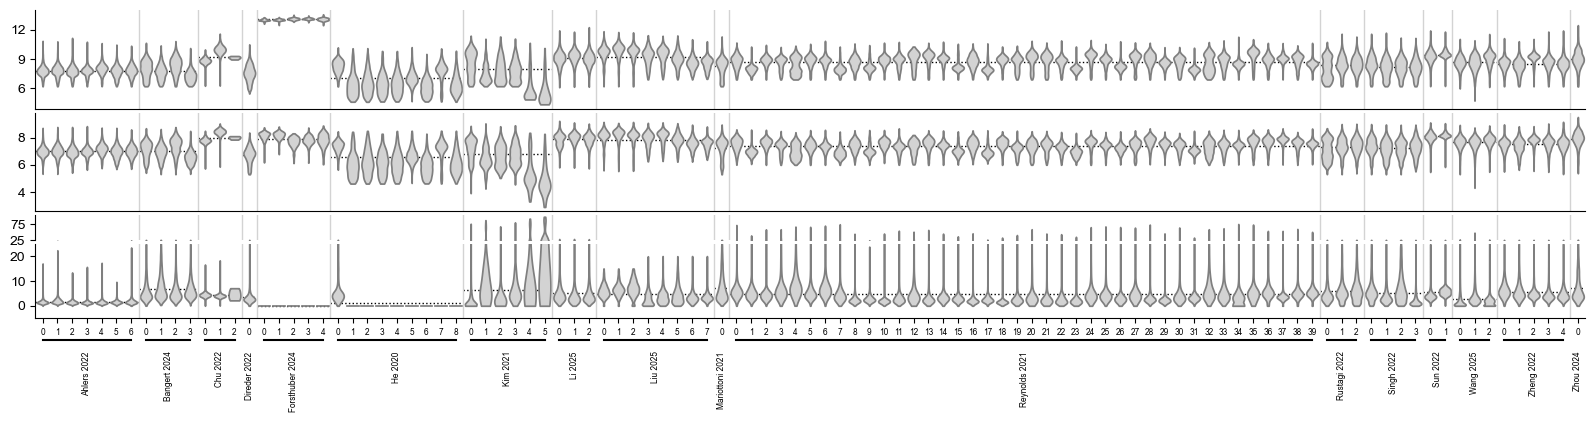

In [57]:
from matplotlib.ticker import MaxNLocator
x = 'donor_id'
qc_metrics = ['log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_mito', 'pct_counts_mito']
fig, axes = initialize_subplots(len(qc_metrics), ncols = 1, figsize_multiplier = (20, 1), gridspec_kw = dict(hspace = 0.05, height_ratios = [4,4,1,3]), sharex = False)

order = plot_df.sort_values(by = ['study_short', 'donor_id'])[x].unique()
for ix, y in enumerate(qc_metrics):
    print(y)
    clear_output(wait = True)
    ax = axes[ix]
    sbn.violinplot(data=plot_df, x=x, y=y, density_norm='width', cut=0, ax=ax, color = 'lightgray', inner = None, order = order)

    ticks = add_annotations_(study_col = 'study_short')

    #ax.set_ylabel(ax.get_ylabel(), fontsize = 6)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    if ix != (len(qc_metrics)-1):
        ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(ticks, fontsize = 6)
    ax.set_xlim([-0.5, len(order)-0.5])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 4))
    
break_point = 25
ax.set_ylim(top = break_point)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))

ax=axes[-2]
ax.set_ylim(bottom = break_point)
ax.spines['bottom'].set_visible(False)
#ax.set_xticks([])
ax.set_yticks([25, 75])
#ax.set_ylabel('Total counts, log(x+1)')
[fig.savefig(os.path.join(fig_path, f'QC_Extended_data_cells_by_donor_total_genes_mito_alphabetical_SS3_Bodysites.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# save extended data

In [11]:
adata.var = adata.var.reset_index(names = 'Ensembl_ID').set_index('feature_name')
adata.var_names = adata.var_names.astype(object)
adata.var_names_make_unique()

In [12]:
out_path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\dataset\UPLOAD_Zenodo')
adata.write_h5ad(os.path.join(out_path, 'HSCA_Extended_all_annotations.h5ad'))

## Filter genes down to sensible biomart list

In [18]:
adata

AnnData object with n_obs × n_vars = 1025007 × 85068
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontol

In [19]:
biomart_df = pd.read_csv('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/sensible_gene_df.csv', index_col = 0)
whitelist = biomart_df['external_gene_name'].values
biomart_df.head()

,ensembl_gene_id,external_gene_name,gene_biotype
0,ENSG00000210049,MT-TF,Mt_tRNA
1,ENSG00000211459,MT-RNR1,Mt_rRNA
2,ENSG00000210077,MT-TV,Mt_tRNA
3,ENSG00000210082,MT-RNR2,Mt_rRNA
4,ENSG00000209082,MT-TL1,Mt_tRNA


In [40]:
adata = adata[:, adata.var_names.intersection(whitelist)].copy()

In [41]:
adata

AnnData object with n_obs × n_vars = 1025007 × 39609
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontol

In [42]:
adata.X = adata.layers['raw_counts'].copy()
del adata.layers['raw_counts']

In [5]:
adata.obs['study_short'] = adata.obs['study_short'].astype(str)
adata.obs.loc[adata.obs['sample_id'].str.startswith('He_Guo'), 'study_short'] = "He Guo 2020"
adata.obs.loc[adata.obs['sample_id'].str.startswith('He_Guttman'), 'study_short'] = "He Guttman 2020"

## Save the updates

In [43]:
adata.write_h5ad(os.path.join(out_path, 'HSCA_Extended_all_annotations_smaller.h5ad'))

## Reload

In [3]:
out_path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\dataset\UPLOAD_Zenodo_smaller')
adata = sc.read_h5ad(os.path.join(out_path, 'HSCA_Extended_all_annotations_smaller.h5ad'), backed = 'r')

# Quick fix of the SS3xpress dataset name

In [41]:
ss3xpress_info = adata.obs.loc[adata.obs['study_id']=='Yuan_in_prep'][columns].drop_duplicates().copy()
ss3xpress_info['donor_id'] = ss3xpress_info['donor_id'].str.split('___').str[1]
ss3xpress_info = ss3xpress_info.sort_values(by = ['donor_id', 'plateID', 'group']).reset_index(drop = True)

In [44]:
ss3xpress_info.to_csv(os.path.join(out_path, 'Smart-seq3xpress_donor_level_metadata.csv'))

# Extra plots

In [15]:
fig_path = convert_path(r'P:\users\Hao\iHSCA_manuscript\Figure_items\Full_dataset')
os.mkdir(fig_path)

## Fig S1a

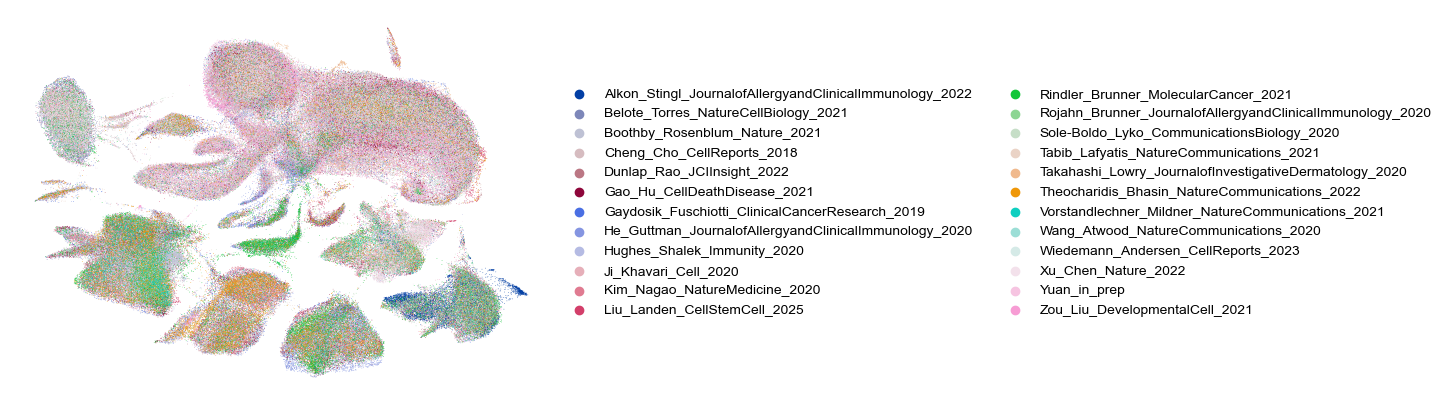

In [16]:
basis = 'integrated_UMAP_L1'

fig, ax = plt.subplots(figsize = (7, 5))

sc.pl.embedding(adata[pd.isna(adata.obs['DataType_Extension'])], basis = basis, color = 'study_id', ax = ax, show = False, frameon = False, s = 1, title = '')

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, 'L1_Full_UMAP_studyID.pdf'), bbox_inches = 'tight', dpi = 600)

## Other extended dataset metadata plots

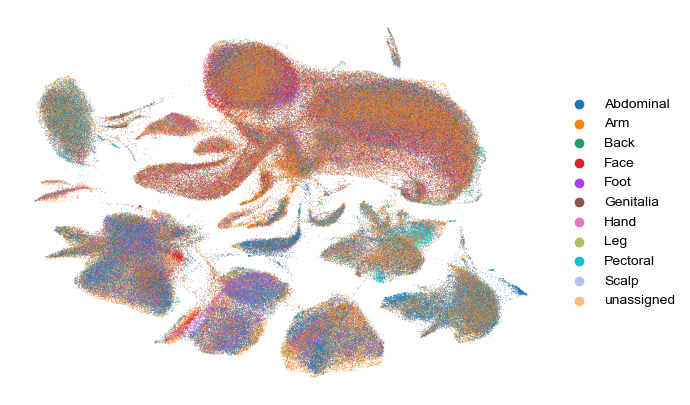

In [18]:
basis = 'integrated_UMAP_L1'
column = 'region_L2'

fig, ax = plt.subplots(figsize = (7, 5))

sc.pl.embedding(adata[pd.isna(adata.obs['DataType_Extension'])], basis = basis, color = column, ax = ax, show = False, frameon = False, s = 1, title = '')

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, f'L1_Full_UMAP_{column}.pdf'), bbox_inches = 'tight', dpi = 600)

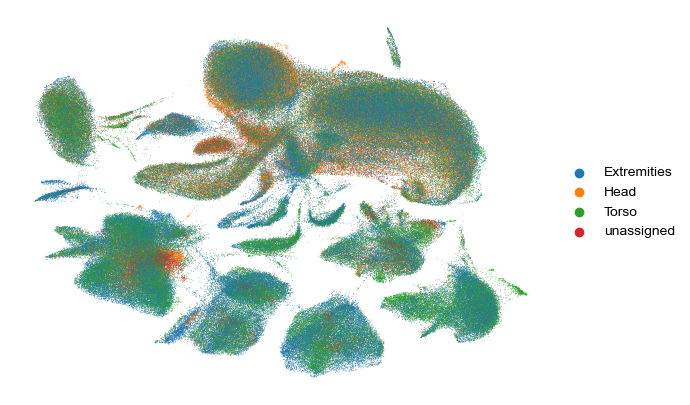

In [21]:
basis = 'integrated_UMAP_L1'
column = 'region_L1'

fig, ax = plt.subplots(figsize = (7, 5))

sc.pl.embedding(adata[pd.isna(adata.obs['DataType_Extension'])], basis = basis, color = column, ax = ax, show = False, frameon = False, s = 1, title = '')

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, f'L1_Full_UMAP_{column}.pdf'), bbox_inches = 'tight', dpi = 600)

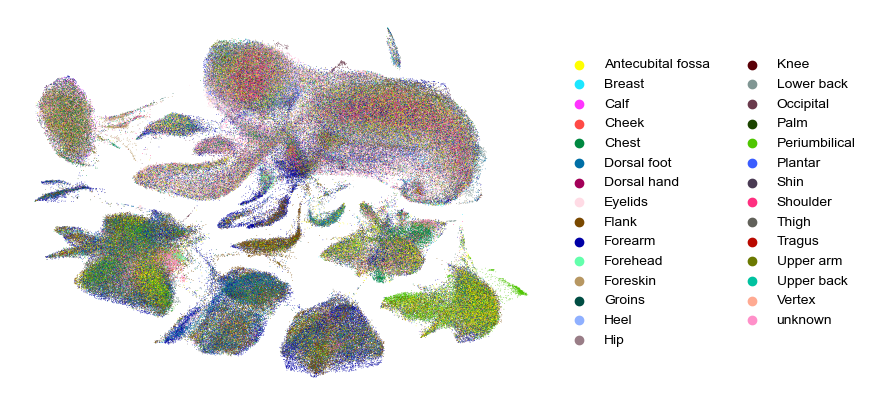

In [20]:
basis = 'integrated_UMAP_L1'
column = 'region_L3'

fig, ax = plt.subplots(figsize = (7, 5))

sc.pl.embedding(adata[pd.isna(adata.obs['DataType_Extension'])], basis = basis, color = column, ax = ax, show = False, frameon = False, s = 1, title = '')

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, f'L1_Full_UMAP_{column}.pdf'), bbox_inches = 'tight', dpi = 600)

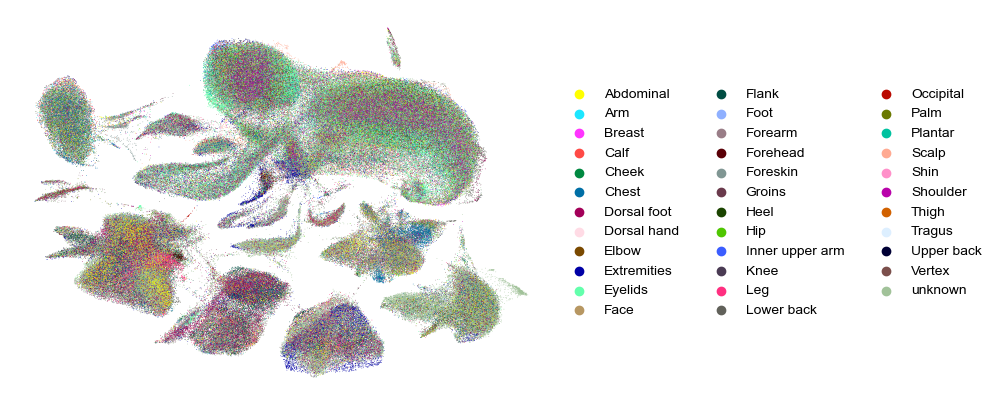

In [24]:
basis = 'integrated_UMAP_L1'
column = 'anatomical_region'

fig, ax = plt.subplots(figsize = (7, 5))

sc.pl.embedding(adata[pd.isna(adata.obs['DataType_Extension'])], basis = basis, color = column, ax = ax, show = False, frameon = False, s = 1, title = '')

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

#fig.savefig(os.path.join(fig_path, f'L1_Full_UMAP_{column}.pdf'), bbox_inches = 'tight', dpi = 600)

In [14]:
adata.obs['Extended_HSCA'] = np.where(~pd.isna(adata.obs['DataType_Extension']), 'Extended', 'Core')

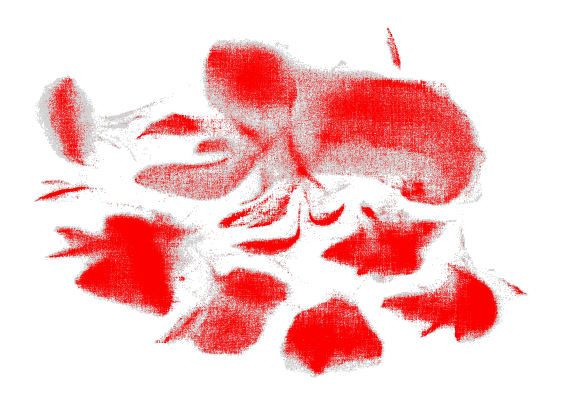

In [41]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata[adata.obs['Extended_HSCA'] != 'Extended'], basis = basis, ax = ax, show = False, frameon = False, s = 2, title = '')
sc.pl.embedding(adata, basis = basis, color = 'Extended_HSCA', groups = ['Extended'], na_in_legend = False, ax = ax, show = False, frameon = False, s = 0.5, title = '', palette = {'Extended': 'red', 'Core': 'lightgray'}, legend_loc = None)

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, 'L1_Extended_UMAP_extended_cells.pdf'), bbox_inches = 'tight', dpi = 600)

In [17]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'
adata.obsm['X_'+basis.lower()] = adata.obsm[basis].copy()
sc.tl.embedding_density(adata, basis = basis, groupby = 'Extended_HSCA')

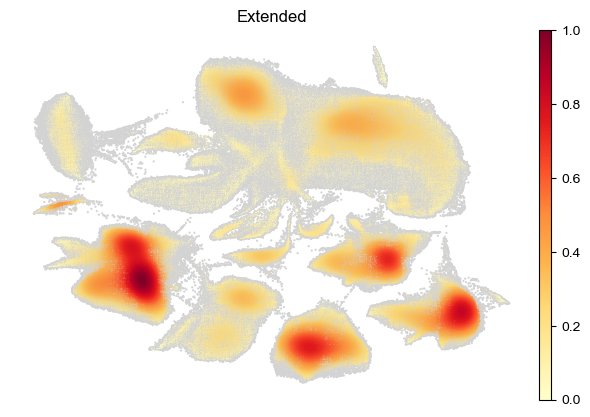

In [33]:
fig_path = convert_path(r'P:\users\Hao\iHSCA_manuscript\Figure_items\Full_dataset')
fig = sc.pl.embedding_density(adata, basis = basis, key = 'integrated_umap_l1_pca_all_ea_k-nn_density_Extended_HSCA', group='Extended', bg_dotsize=10, fg_dotsize=0.5, frameon = False, return_fig=True, show = False)

ax = fig.get_axes()[0]
for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, 'L1_Extended_UMAP_embedding_density.pdf'), bbox_inches = 'tight', dpi = 600)

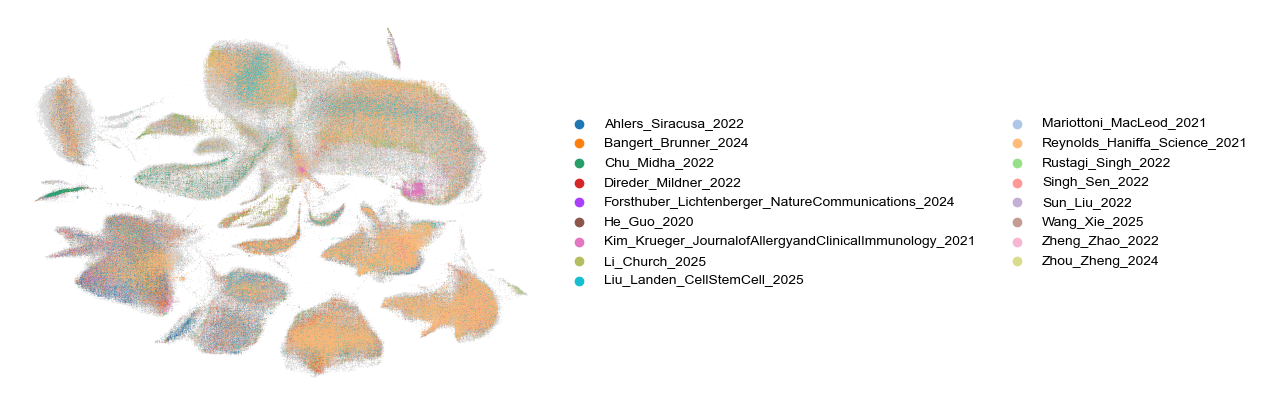

In [42]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))

sc.pl.embedding(adata[adata.obs['Extended_HSCA'] != 'Extended'], basis = basis, ax = ax, show = False, frameon = False, s = 1, title = '')
sc.pl.embedding(adata[adata.obs['Extended_HSCA'] == 'Extended'], basis = basis, color = 'study_id', na_in_legend = False, ax = ax, show = False, frameon = False, s = 0.5, title = '')

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)

fig.savefig(os.path.join(fig_path, 'L1_Extended_UMAP_study_id.pdf'), bbox_inches = 'tight', dpi = 600)

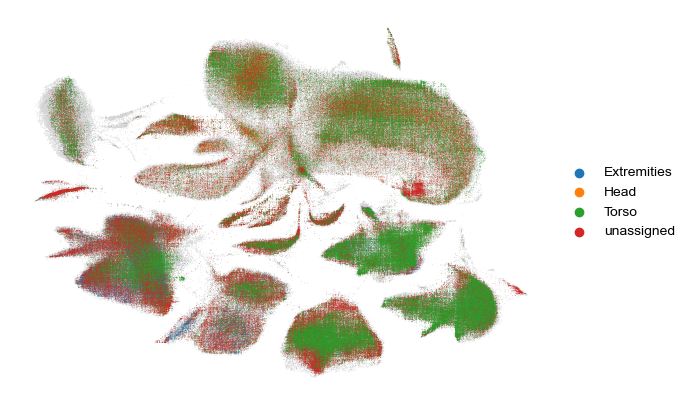

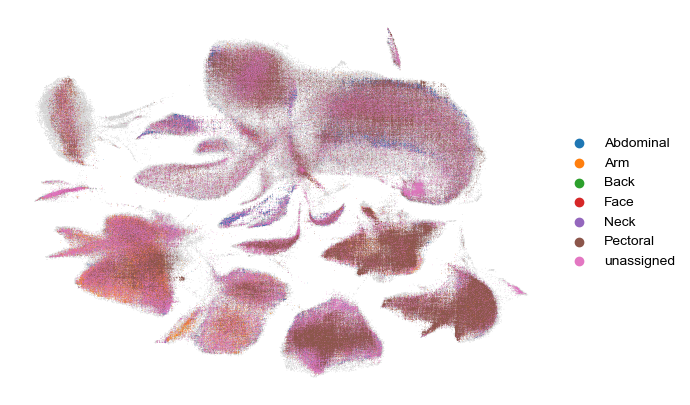

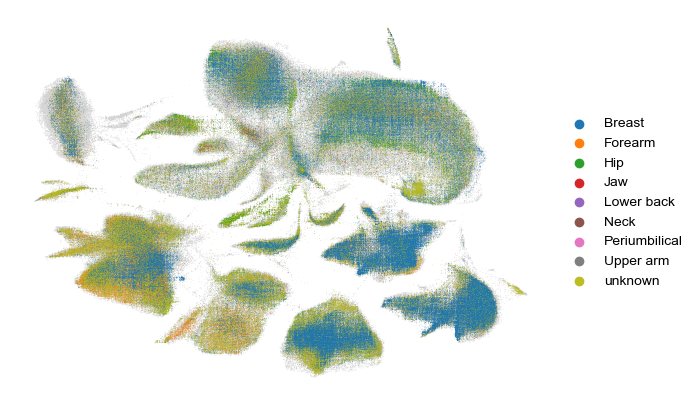

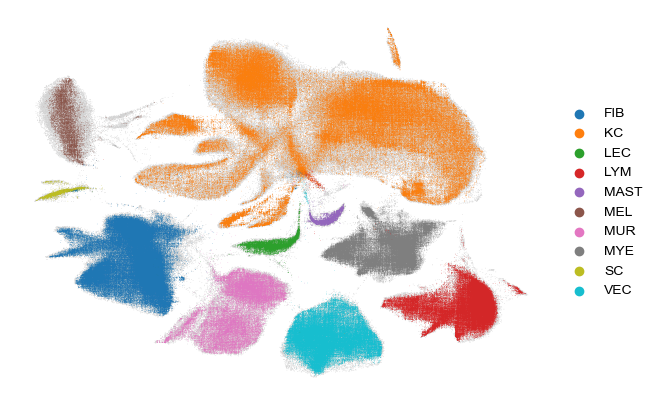

In [52]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'
column = 'region_L2'

for column in ['region_L1', 'region_L2', 'region_L3', 'integrated_annotation_L1_k-NN']:
    fig, ax = plt.subplots(figsize = (7, 5))
    
    sc.pl.embedding(adata[adata.obs['Extended_HSCA'] != 'Extended'], basis = basis, ax = ax, show = False, frameon = False, s = 1, title = '')
    sc.pl.embedding(adata[adata.obs['Extended_HSCA'] == 'Extended'], basis = basis, color = column, na_in_legend = False, ax = ax, show = False, frameon = False, s = 0.5, title = '')
    
    for coll in ax.collections:
        if isinstance(coll, mpl.collections.PathCollection):
            coll.set_rasterized(True)
    
    fig.savefig(os.path.join(fig_path, f'L1_Extended_UMAP_{column}.pdf'), bbox_inches = 'tight', dpi = 600)

In [78]:
order = [
    'F1',
    'F2',
    'F3',
    'FB1',
    'FB2',
    'Fibroblasts',
    'Bas1',
    'Bas2',
    'BasProlif',
    'Differentiated_KC',
    'Differentiated_KC*',
    'Gra',
    'HF',
    'Keratinocytes',
    'Proliferating_KC',
    'Spi',
    'Undifferentiated_KC',
    
    'LE',
    'LE1',
    'LE2',
    
    'ILC1_3',
    'ILC1_NK',
    'ILC2',
    'Immune',
    'NK',
    'NKs',
    'Plasma',
    'Tc',
    'Th',
    'Ths',
    'Treg',
    
    'Mast',
    'Mast_cell',
    
    'MEL',
    'Melanocyte',
    'Melanocytes',
    
    
    'Pericyte_1',
    'Pericyte_2',
    'Pericytes',
    'Pericytes_vSMCs',
    'SMCs',
    
    'DC1',
    'DC2',
    'DC_Blympho',
    'Inf_mac',
    'LC_1',
    'LC_2',
    'LC_3',
    'LC_4',
    'Mac1',
    'Mac2',
    'Macro_1',
    'Macro_2',
    'MigDC',
    'Mono_mac',
    'moDC_1',
    'moDC_2',
    'moDC_3',
    
    'Schwann_1',
    'Schwann_2',
    
    'Endothelial',
    'VE',
    'VE1',
    'VE2',
    'VE3',
    'artVE',
    
    'unknown'
]

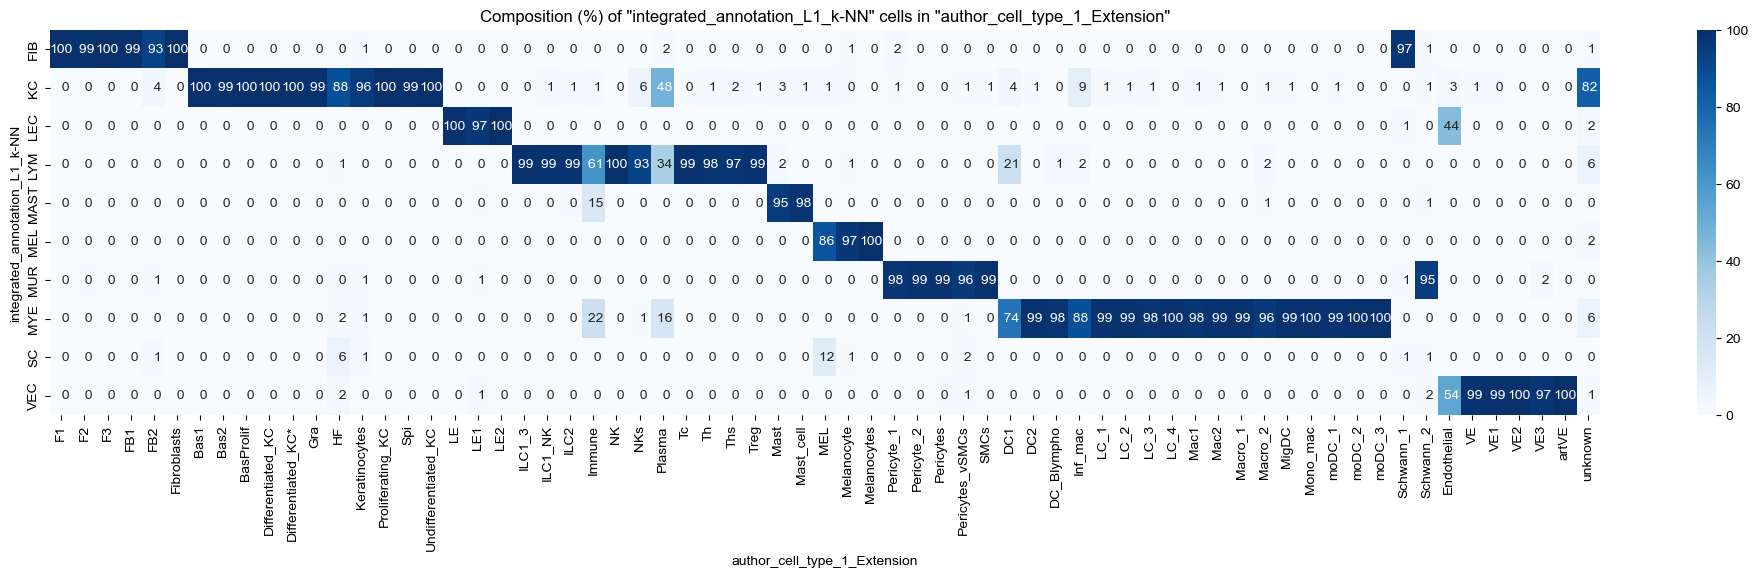

In [80]:
fig, ax = plt.subplots(figsize = (25, 5))
df = plot_group_composition_heatmap(adata.obs, groupby_name='author_cell_type_1_Extension', count_group_name='integrated_annotation_L1_k-NN', ax = ax, cmap = 'Blues', transpose=True, order_columns = order)

fig.savefig(os.path.join(fig_path, f'L1_Extended_Dotplot_composition.pdf'), bbox_inches = 'tight', dpi = 600)